# 1.3 Data Visualization Lab

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the Spotify Dataset

In [4]:
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Top 10 Artists

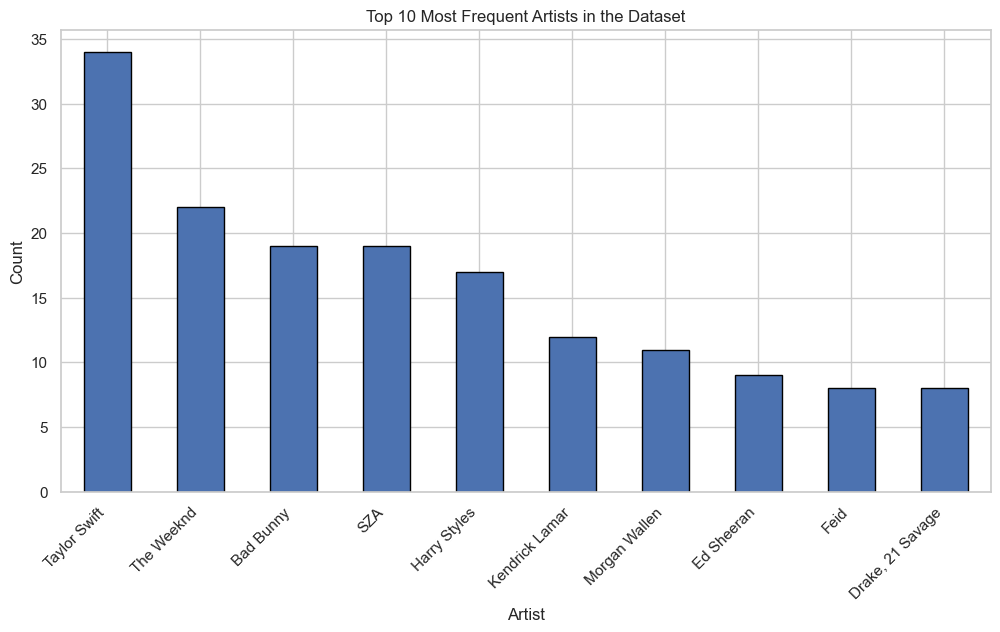

In [22]:
plt.figure(figsize=(12,6))
df['artist(s)_name'].value_counts().head(10).plot(kind='bar', edgecolor='black')
plt.title('Top 10 Most Frequent Artists in the Dataset')
plt.xlabel('Artist')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

## 1. BPM (Histogram)

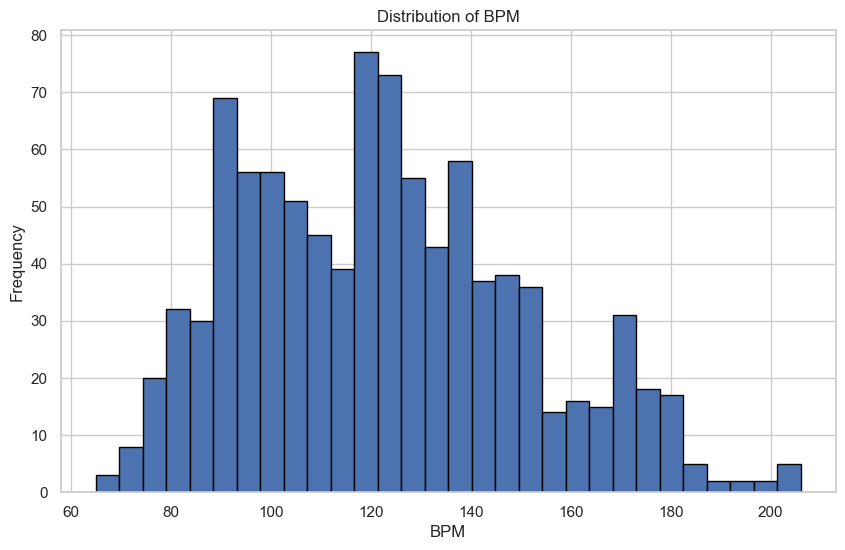

In [5]:
plt.figure(figsize=(10,6))
plt.hist(df['bpm'], bins=30, edgecolor='black')
plt.title('Distribution of BPM')
plt.xlabel('BPM')
plt.ylabel('Frequency')
plt.show()

- BPM is typically between 120-130
- Distribution is centerd around the mid-tempo pop range
- Right-skewed with some very fast songs

## 2. Key (Bar Chart)

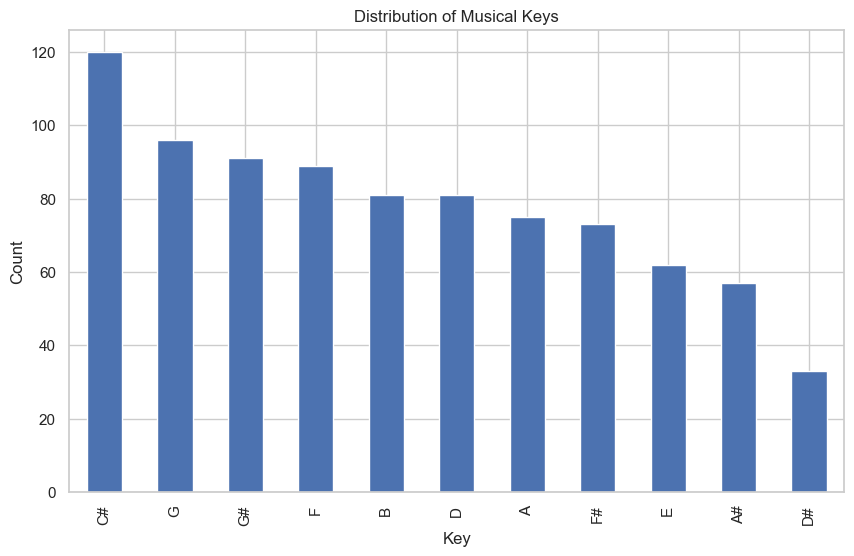

In [7]:
df['key'].value_counts().plot(kind='bar', figsize=(10,6))
plt.title('Distribution of Musical Keys')
plt.xlabel('Key')
plt.ylabel('Count')
plt.show()

### Key Distribution (Summary)

C# is the most common key by a wide margin. A few keys like G, G#, F, and B appear moderately often, while keys such as D# are much less frequent. Overall, I find popular songs tend to cluster around a small set of preferred keys.

## 3. Mode (Bar Chart)

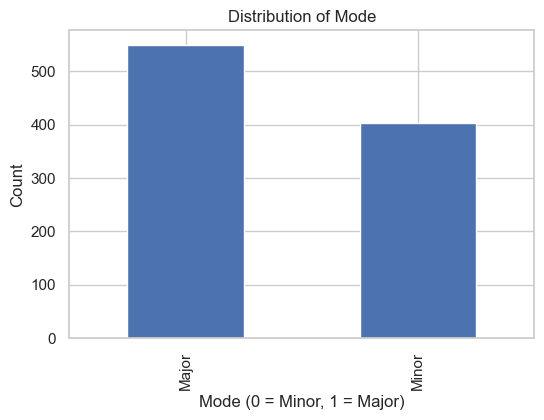

In [10]:
df['mode'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title('Distribution of Mode')
plt.xlabel('Mode (0 = Minor, 1 = Major)')
plt.ylabel('Count')
plt.show()

### Mode Distribution (Summary)

Major mode 1 appears slightly more often than minor mode (0), with about 550 major songs and 400 minor songs. The difference isn't dramatic, but it does show a preference for major tonality in popular music.

## 4. Danceability (Histogram)

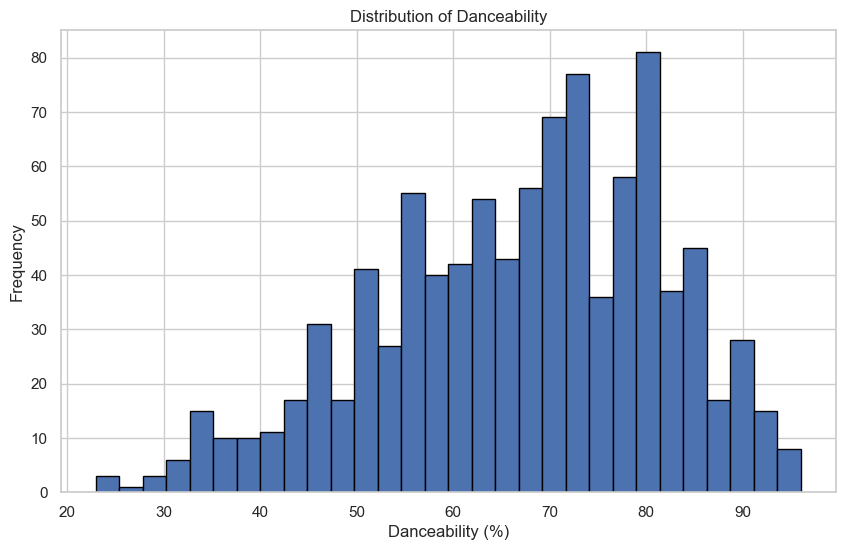

In [13]:
plt.figure(figsize=(10,6))
plt.hist(df['danceability_%'], bins=30, edgecolor='black')
plt.title('Distribution of Danceability')
plt.xlabel('Danceability (%)')
plt.ylabel('Frequency')
plt.show()

### Danceability Distribution (Summary)
Most songs fall between 60% and 80% danceability, with a clear peak around the mid‑70% range. The distribution is slightly right‑skewed, suggesting that highly danceable tracks are more common in the dataset.

## 5. Energy (Histogram)

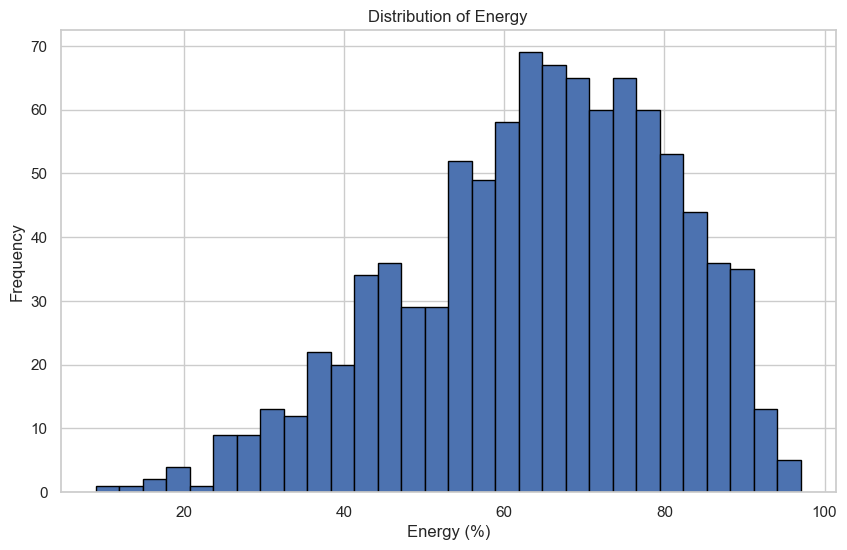

In [14]:
plt.figure(figsize=(10,6))
plt.hist(df['energy_%'], bins=30, edgecolor='black')
plt.title('Distribution of Energy')
plt.xlabel('Energy (%)')
plt.ylabel('Frequency')
plt.show()

### Energy Distribution (Summary)
Energy levels cluster mostly between 60% and 70%, with a noticeable peak in that range. The distribution is slightly right‑skewed, showing that high‑energy tracks are common in the dataset.

## 6. Speechiness (Histogram)

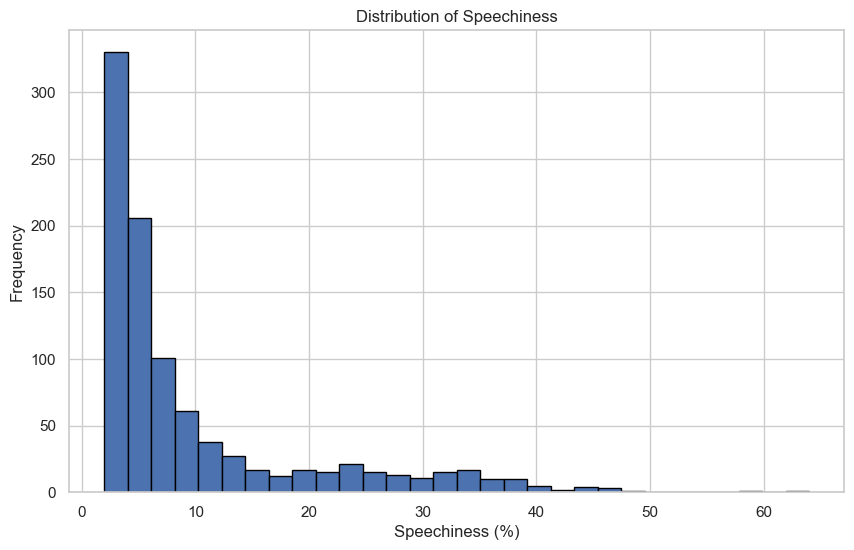

In [15]:
plt.figure(figsize=(10,6))
plt.hist(df['speechiness_%'], bins=30, edgecolor='black')
plt.title('Distribution of Speechiness')
plt.xlabel('Speechiness (%)')
plt.ylabel('Frequency')
plt.show()

### Speechiness Distribution (Summary)
Speechiness is heavily concentrated at very low values, with most songs showing minimal spoken content. The frequency drops sharply as speechiness increases, indicating that highly speech‑based tracks are rare in this dataset.

## 7. Acousticness (Histogram)

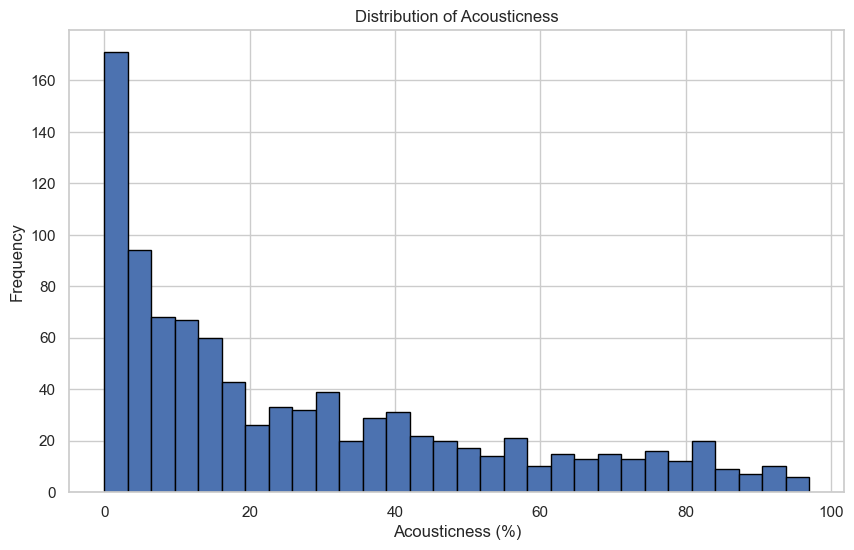

In [16]:
plt.figure(figsize=(10,6))
plt.hist(df['acousticness_%'], bins=30, edgecolor='black')
plt.title('Distribution of Acousticness')
plt.xlabel('Acousticness (%)')
plt.ylabel('Frequency')
plt.show()

### Acousticness Distribution (Summary)
Acousticness is heavily concentrated at low values, with most songs showing very little acoustic character. Higher acousticness levels become increasingly rare, indicating that fully acoustic tracks are uncommon in this dataset.

### Typical Values for a Guaranteed Smash Hit

Based on the distributions in the dataset, the following values represent the most common or “typical” characteristics of popular songs:

- **BPM:** 120–140  
  Most songs cluster in this tempo range, making it the most typical for a hit.

- **Key:** C#  
  This was the most frequent key in the dataset.

- **Mode:** Major (1)  
  Major mode appears slightly more often than minor.

- **Danceability:** 60–80%  
  The histogram shows a strong concentration in this mid‑high range.

- **Energy:** 60–80%  
  Similar to danceability, most songs fall in this energetic but not extreme range.

- **Speechiness:** 0–10%  
  The distribution is heavily skewed toward very low speechiness.

- **Acousticness:** 0–20%  
  Most songs have low acousticness, indicating a preference for more produced, electronic, or pop‑leaning sounds.

### Do any songs meet all the hit criteria?

In [19]:
# Define hit criteria
hit_songs = df[
    (df['bpm'].between(120, 140)) &
    (df['key'] == 'C#') &
    (df['mode'] == 1) &
    (df['danceability_%'].between(60, 80)) &
    (df['energy_%'].between(60, 80)) &
    (df['speechiness_%'].between(0, 10)) &
    (df['acousticness_%'].between(0, 20))
]

hit_songs[['track_name', 'artist(s)_name', 'streams']]

,track_name,artist(s)_name,streams


Using the criteria derived from the visualizations, no songs in the dataset met all seven conditions simultaneously. This suggests that while the ranges I identified describe common patterns among popular songs, they do not uniquely identify a single "perfect" hit. Instead, songs vary and may fall outside one or more of the typical ranges.

## Pick a Song (As It Was - Harry Styles)

In [21]:
df[df['track_name'].str.contains("As It Was", case=False)][
    ['track_name','artist(s)_name','bpm','key','mode',
     'danceability_%','energy_%','speechiness_%','acousticness_%']
]

,track_name,artist(s)_name,bpm,key,mode,danceability_%,energy_%,speechiness_%,acousticness_%
14,As It Was,Harry Styles,174,F#,Minor,52,73,6,34


### Comparison to a Known Smash Hit: *As It Was* by Harry Styles
The song As It Was appears in the dataset and provides a useful comparison to the hit‑song criteria. Its BPM of 174 is much higher than the typical 120–140 BPM range identified, showing that hit songs can succeed even with unusually fast tempos. The track’s energy (73%) and speechiness (6%) fall squarely within the common ranges found in the dataset, while its danceability (52%) is slightly below the 60–80% range but still moderate. Its acousticness (34%) is higher than the typical low‑acousticness profile, and it is written in F# minor rather than the more common major keys. Overall, As It Was demonstrates that while many hit songs share common audio‑feature patterns, successful tracks often break one or more of these trends.